In [11]:
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import matplotlib.pyplot as plt

In [12]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10

# Convergence Analysis 

In [202]:
# keys are (instance, seed) pairs
dict_convergence = {}

for file in glob.glob("benchmark-convergence_results/*"):
    filepath = Path(file)
    try:
        instance, seed = filepath.stem.split("_")[1:] 
        dict_convergence[instance,int(seed)] = pd.read_csv(filepath, sep=";")
    except Exception as e:
        stem = filepath.stem.split("_")
        if len(stem) > 2: ### instancias Diego
            instance, seed = "_".join(stem[1:3]), int(stem[-1])
            dict_convergence[instance, seed] = pd.read_csv(filepath, sep=";")

In [203]:
instances = ['bacp7_diego', 'bacp8', 'bacp10', 'bacp10_diego', 'bacp12']

rename_instance_dict = {
    'bacp7_diego' : 'bacp7_real',
    'bacp10_diego' : 'bacp10_real',
    'bacp11v2' : 'bacp11_perceived' 
}

seeds = sorted(set(key[1] for key in dict_convergence.keys()))
instances, seeds

(['bacp7_diego', 'bacp8', 'bacp10', 'bacp10_diego', 'bacp12'],
 [11, 108, 121, 123, 135, 151, 255, 268, 326, 501])

/home/csori/workspace/memoria/memo/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


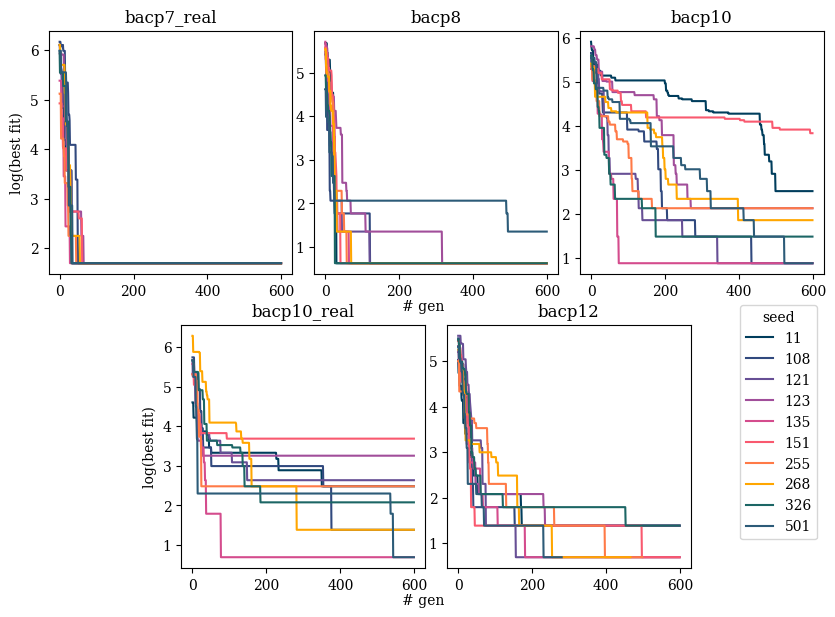

In [209]:
### plot convergence graphs for each instance

fig = plt.figure(figsize=(10,7))
axs_ab  = [plt.subplot2grid((2, 6), (0, i * 2),     colspan=2) for i in range(3)]
axs_bel = [plt.subplot2grid((2, 6), (1, 1 + i * 2), colspan=2) for i in range(2)]


seed_colors = {
    11 : "#003d5c",
    108 : "#31497e",
    121 : "#674f95",
    123 : "#a14e9a",
    135 : "#d44c8d",
    151 : "#f9596f",
    255 : "#ff7a47",
    268 : "#ffa600",
    326 : "#1c6665",
    501 : "#2c5b78",
}

for i, instance in enumerate(instances[:3]):
    for seed in seeds:
        df_convergence = dict_convergence[instance, seed]
        axs_ab[i].plot(df_convergence[r"# gen"], np.log(df_convergence["best_fit"]), color=seed_colors[seed], label=seed)
    axs_ab[i].set_title(rename_instance_dict[instance] if instance in rename_instance_dict else instance)
    
for i, instance in enumerate(instances[3:]):
    for seed in seeds:
        df_convergence = dict_convergence[instance, seed]
        axs_bel[i].plot(df_convergence[r"# gen"], np.log(df_convergence["best_fit"]), color=seed_colors[seed], label=seed)
    axs_bel[i].set_title(rename_instance_dict[instance] if instance in rename_instance_dict else instance)

for ax in axs_ab + axs_bel:
    ax.set_box_aspect(1)

axs_ab[0].set_ylabel("log(best fit)")
axs_bel[0].set_ylabel("log(best fit)")

fig.text(0.5, 0.48, "# gen", ha="center")   # under the top row
fig.text(0.5, 0.06, "# gen", ha="center")   # under the bottom row

handles = [plt.Line2D([0], [0], color=color, label=seed)
           for seed, color in seed_colors.items()]

fig.legend(handles=handles, title="seed",
           loc="center right", bbox_to_anchor=(0.9,0.32))

plt.savefig("convergencegraphs.pdf", format='pdf')
plt.show()

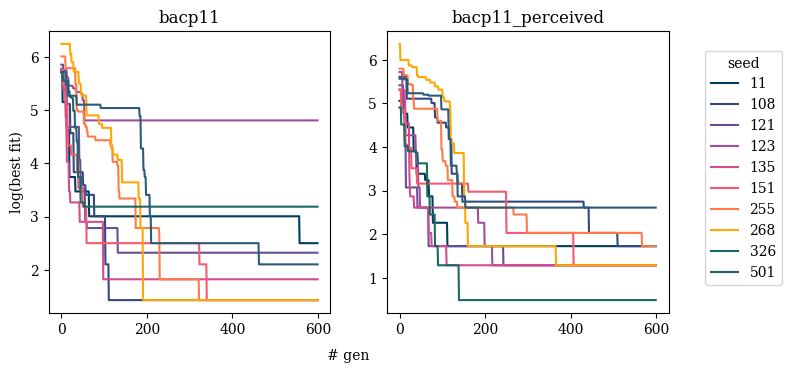

In [207]:
fig, ax = plt.subplots(1,2,figsize=(8,8))

for i, instance in enumerate(['bacp11', 'bacp11v2']):
    for seed in seeds:
        df_convergence = dict_convergence[instance, seed]
        ax[i].plot(df_convergence[r"# gen"], np.log(df_convergence["best_fit"]), color=seed_colors[seed], label=seed)
    ax[i].set_title(rename_instance_dict[instance] if instance in rename_instance_dict else instance)

for axi in ax:
    axi.set_box_aspect(1)

ax[0].set_ylabel("log(best fit)")
fig.text(0.5, 0.26, "# gen", ha="center")   # under the bottom row

handles = [plt.Line2D([0], [0], color=color, label=seed)
           for seed, color in seed_colors.items()]

fig.legend(handles=handles, title="seed",
           loc="center right", bbox_to_anchor=(1.05,0.5))

plt.savefig("convergencegraphs_11.pdf", format='pdf',  bbox_inches='tight')
plt.show()

# Per-instance solutions

In [155]:
# keys are (instance, seed) pairs
dict_solutions = {}

for file in glob.glob("benchmark-solutions/*"):
    filepath = Path(file)
    try:
        instance, seed = filepath.stem.split("_")[1:] 
        dict_solutions[instance,int(seed)] = pd.read_csv(filepath, sep=";")
    except Exception as e:
        stem = filepath.stem.split("_")
        if len(stem) > 2: ### instancias Diego
            instance, seed = "_".join(stem[1:3]), int(stem[-1])
            dict_solutions[instance, seed] = pd.read_csv(filepath, sep=";")

In [198]:
import itertools

best_sols = {}
num_periods = {}
num_courses = {}

for instance in instances+['bacp11', 'bacp11v2']:
    df_solution = pd.DataFrame()
    for seed in seeds:
        sol = dict_solutions[instance, seed].loc[lambda x: x.id_sol == 1, ["period", "courses", "total_credits", "period_fit", "total_fit"]]
        sol["seed"] = seed
        df_solution = pd.concat([df_solution, sol])
    group = df_solution.loc[lambda x: x.total_fit == df_solution.total_fit.min()]
    mask_seed = group.seed == group.seed.values[0]
    num_periods[rename_instance_dict[instance] if instance in rename_instance_dict else instance] = group.loc[mask_seed].period.nunique()
    num_courses[rename_instance_dict[instance] if instance in rename_instance_dict else instance] = group.loc[mask_seed].courses.str.count(r'\w+\d+').sum()

    df_sol = group.loc[mask_seed].rename(
        {'period': 'Period', 'total_credits': 'Period Credits', 'period_fit' : 'Period Fitness'}, axis=1
    ).drop(['seed', 'total_fit', 'courses'], axis=1)
    df_sol = pd.concat([df_sol, pd.DataFrame({
        'Period': ['Total'], 
        'Period Credits' : [df_sol['Period Credits'].sum()], 
        'Period Fitness': [df_sol['Period Fitness'].sum()]
    })])
    best_sols[rename_instance_dict[instance] if instance in rename_instance_dict else instance] = df_sol.set_index('Period')

In [199]:
for instance, df_sol in best_sols.items():
    df_sol.to_latex(
        f"tables/best_solution_{instance}.tex", 
        float_format="%.5f", 
        bold_rows=True, 
        caption=f"Final solution for instance {instance} - {num_periods[instance]} periods {num_courses[instance]} courses", 
        label=f"tab:sol_{instance}"
    )

# DBACP Instances

In [15]:
dict_dynamic_sol = {}

for file in glob.glob("DBACP-dynamics_solutions/*.csv"):
    filepath = Path(file)
    instance_code = filepath.stem.split("_")[3].strip()
    seed = int(filepath.stem.split("_")[-1].strip())
    dict_dynamic_sol[instance_code, seed] = pd.read_csv(filepath, sep= ";")    

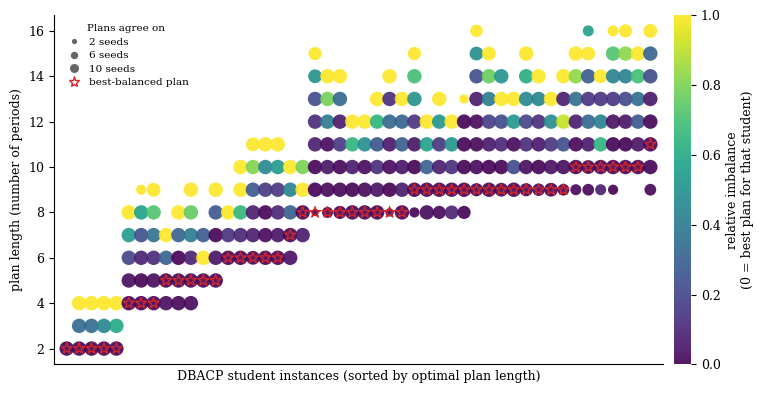

In [28]:
instances = sorted({k[0] for k in dict_dynamic_sol})
seeds     = sorted({k[1] for k in dict_dynamic_sol})

# per instance: length -> (best fit across seeds, #seeds reaching it)
per_instance = {}
for inst in instances:
    length_best, length_cnt = {}, {}
    for s in seeds:
        df = dict_dynamic_sol.get((inst, s))
        if df is None or len(df) == 0:
            continue
        for L, fit in df.groupby("total_periods")["total_fit"].min().items():
            length_cnt[L] = length_cnt.get(L, 0) + 1
            if L not in length_best or fit < length_best[L]:
                length_best[L] = fit
    if length_best:
        per_instance[inst] = (length_best, length_cnt)

best_len = lambda inst: min(per_instance[inst][0], key=per_instance[inst][0].get)
order = sorted(per_instance, key=lambda i: (best_len(i), min(per_instance[i][0])))

xs, ys, sizes, colors, star_x, star_y = [], [], [], [], [], []
for xi, inst in enumerate(order):
    lb, lc = per_instance[inst]
    fits = np.array(list(lb.values()), float)
    span = (fits.max() - fits.min()) or 1.0
    for L, fit in lb.items():
        xs.append(xi); ys.append(L); sizes.append(lc[L])
        colors.append((fit - fits.min()) / span)
    star_x.append(xi); star_y.append(best_len(inst))

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(xs, ys, c=colors, cmap="viridis",
                s=18 + np.array(sizes) * 9, linewidths=0, alpha=0.9, zorder=3)
ax.scatter(star_x, star_y, marker="*", s=70, facecolor="none",
           edgecolor="#d62728", linewidths=0.9, zorder=4)
ax.set_xlabel("DBACP student instances (sorted by optimal plan length)")
ax.set_ylabel("plan length (number of periods)")
ax.set_xlim(-1, len(order)); ax.set_xticks([])
# ax.grid(axis="y", color="0.9", linewidth=0.6)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)

cbar = fig.colorbar(sc, ax=ax, pad=0.015)
cbar.set_label("relative imbalance\n(0 = best plan for that student)")
cbar.outline.set_visible(False)

size_handles = [plt.Line2D([], [], marker="o", linestyle="none",
                markersize=np.sqrt(18 + n*9)/1.6, markerfacecolor="0.4",
                markeredgecolor="none", label=f"{n} seeds") for n in (2, 6, 10)]
star_handle = plt.Line2D([], [], marker="*", linestyle="none", markersize=8,
              markerfacecolor="none", markeredgecolor="#d62728", label="best-balanced plan")
ax.legend(handles=size_handles + [star_handle], title="Plans agree on",
          loc="upper left", frameon=False, fontsize=7.5, title_fontsize=7.5,
          handletextpad=0.4, labelspacing=0.4)
fig.tight_layout()
fig.savefig("dbacp_diversity.pdf", bbox_inches="tight", dpi=300)
plt.show()

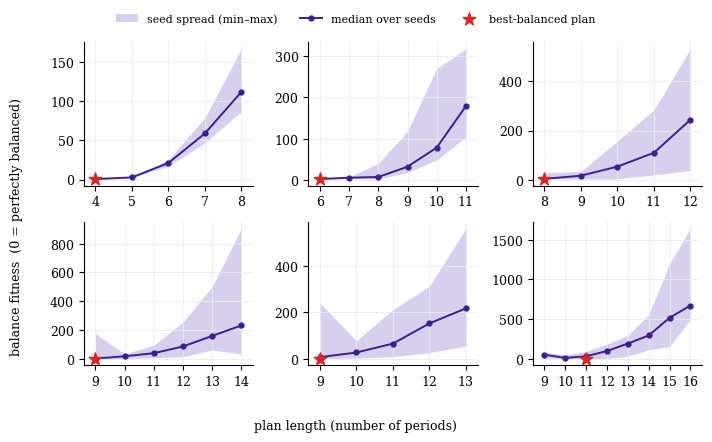

In [30]:
seeds = sorted({k[1] for k in dict_dynamic_sol})

def frontier(inst):
    d = {}
    for s in seeds:
        df = dict_dynamic_sol.get((inst, s))
        if df is None or len(df) == 0:
            continue
        for L, fit in df.groupby("total_periods")["total_fit"].min().items():
            d.setdefault(L, []).append(fit)
    return d

instances = sorted({k[0] for k in dict_dynamic_sol})
fronts = {i: frontier(i) for i in instances}
fronts = {i: f for i, f in fronts.items() if len(f) >= 5}
opt_len = lambda inst: min(fronts[inst], key=lambda L: min(fronts[inst][L]))

ranked = sorted(fronts, key=opt_len)
picks = [ranked[i] for i in dict.fromkeys(np.linspace(0, len(ranked)-1, 6).round().astype(int))]

# plt.rcParams.update({"font.size": 9})
fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.2))
line_c, band_c, star_c = "#3b1f8b", "#b7a8e0", "#d62728"

for ax, inst in zip(axes.flat, picks):
    f = fronts[inst]; Ls = sorted(f)
    med = [np.median(f[L]) for L in Ls]
    lo  = [np.min(f[L])    for L in Ls]
    hi  = [np.max(f[L])    for L in Ls]
    ax.fill_between(Ls, lo, hi, color=band_c, alpha=0.55, lw=0, label="seed spread (min–max)")
    ax.plot(Ls, med, "-o", color=line_c, ms=3.5, lw=1.4, label="median over seeds")
    bL = opt_len(inst)
    ax.scatter([bL], [min(f[bL])], marker="*", s=90, color=star_c, zorder=5, label="best-balanced plan")
    ax.grid(color="0.92", lw=0.6); ax.margins(x=0.08)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)

fig.supxlabel("plan length (number of periods)", fontsize=9)
fig.supylabel("balance fitness  (0 = perfectly balanced)", fontsize=9)
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=3, frameon=False, fontsize=8)
fig.tight_layout(rect=(0.02, 0.02, 1, 0.97))
fig.savefig("dbacp_frontier.pdf", bbox_inches="tight")
plt.show()